In [ ]:
import pandas as pd
metadata = pd.read_csv('/kaggle/input/skin-cancer/metadata.csv')
print(metadata.info())
print(metadata.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2298 entries, 0 to 2297
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2298 non-null   object 
 1   lesion_id            2298 non-null   int64  
 2   smoke                1494 non-null   object 
 3   drink                1494 non-null   object 
 4   background_father    1480 non-null   object 
 5   background_mother    1476 non-null   object 
 6   age                  2298 non-null   int64  
 7   pesticide            1494 non-null   object 
 8   gender               1494 non-null   object 
 9   skin_cancer_history  1494 non-null   object 
 10  cancer_history       1494 non-null   object 
 11  has_piped_water      1494 non-null   object 
 12  has_sewage_system    1494 non-null   object 
 13  fitspatrick          1494 non-null   float64
 14  region               2298 non-null   object 
 15  diameter_1           1494 non-null   f

In [ ]:
metadata['diagnostic_grouped'] = metadata['diagnostic'].apply(
    lambda x: 'skin_cancer' if x in ['BCC', 'MEL', 'SCC'] else 'skin_disease'
)
print(metadata[['diagnostic', 'diagnostic_grouped']].head())

  diagnostic diagnostic_grouped
0        NEV       skin_disease
1        BCC        skin_cancer
2        ACK       skin_disease
3        ACK       skin_disease
4        BCC        skin_cancer


In [ ]:
from sklearn.preprocessing import LabelEncoder
metadata = metadata.drop(columns=['diagnostic'])
label_encoder = LabelEncoder()
metadata['diagnostic_grouped'] = label_encoder.fit_transform(metadata['diagnostic_grouped'])
print(metadata[['diagnostic_grouped']].head())

   diagnostic_grouped
0                   1
1                   0
2                   1
3                   1
4                   0


diagnostic_grouped
1    1209
0    1089
Name: count, dtype: int64


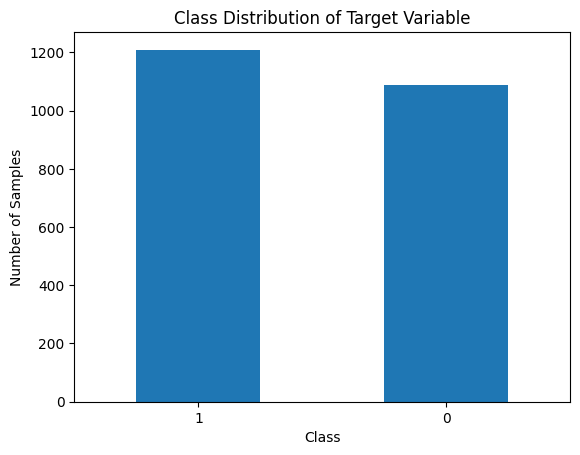

In [ ]:
class_distribution = metadata['diagnostic_grouped'].value_counts()
print(class_distribution)
import matplotlib.pyplot as plt
class_distribution.plot(kind='bar', title='Class Distribution of Target Variable')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
drop_cols = ['smoke', 'drink', 'background_father', 'background_mother', 
             'pesticide', 'gender', 'has_piped_water', 'has_sewage_system']
metadata.drop(columns=drop_cols, inplace=True)

In [12]:
metadata.loc[:, 'fitspatrick'] = metadata['fitspatrick'].fillna(metadata['fitspatrick'].median())
metadata.loc[:, 'diameter_1'] = metadata['diameter_1'].fillna(metadata['diameter_1'].median())
metadata.loc[:, 'diameter_2'] = metadata['diameter_2'].fillna(metadata['diameter_2'].median())

In [ ]:
metadata['biopsed'] = metadata['biopsed'].map({True: 1, False: 0})
print(metadata['biopsed'].unique())

[0 1]


In [ ]:
import numpy as np
metadata['elevation'] = metadata['elevation'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan}).infer_objects()
print(metadata['elevation'].unique())

[ 0.  1. nan]


/tmp/ipykernel_316/3162232629.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['elevation'] = metadata['elevation'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan}).infer_objects()


In [ ]:
mode_val = metadata['elevation'].mode()[0]
metadata['elevation'] = metadata['elevation'].fillna(mode_val)
print(metadata['elevation'].unique())

[0. 1.]


In [ ]:
metadata['itch'] = metadata['itch'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})
metadata['itch'] = pd.to_numeric(metadata['itch'], errors='coerce')
mode_val = metadata['itch'].mode()[0]
metadata['itch'] = metadata['itch'].fillna(mode_val)
print(metadata['itch'].unique())

[0. 1.]


/tmp/ipykernel_316/925289227.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['itch'] = metadata['itch'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})


In [ ]:
metadata['hurt'] = metadata['hurt'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})
metadata['hurt'] = pd.to_numeric(metadata['hurt'], errors='coerce')
mode_val = metadata['hurt'].mode()[0]
metadata['hurt'] = metadata['hurt'].fillna(mode_val)
print(metadata['hurt'].unique())

[0. 1.]


/tmp/ipykernel_316/1500104836.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['hurt'] = metadata['hurt'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})


In [ ]:
metadata['grew'] = metadata['grew'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})
metadata['grew'] = pd.to_numeric(metadata['grew'], errors='coerce')
mode_val = metadata['grew'].mode()[0]
metadata['grew'] = metadata['grew'].fillna(mode_val)
print(metadata['grew'].unique())

[0. 1.]


/tmp/ipykernel_316/118914609.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['grew'] = metadata['grew'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})


In [ ]:
metadata['bleed'] = metadata['bleed'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})
metadata['bleed'] = pd.to_numeric(metadata['bleed'], errors='coerce')
mode_val = metadata['bleed'].mode()[0]
metadata['bleed'] = metadata['bleed'].fillna(mode_val)
print(metadata['bleed'].unique())

[0. 1.]


/tmp/ipykernel_316/1677100598.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['bleed'] = metadata['bleed'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})


In [ ]:
metadata['changed'] = metadata['changed'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})
metadata['changed'] = metadata['changed'].astype(float)
mode_val = metadata['changed'].mode()[0]
metadata['changed'] = metadata['changed'].fillna(mode_val)
print(metadata['changed'].unique())

[0. 1.]


/tmp/ipykernel_316/3470457348.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['changed'] = metadata['changed'].replace({'TRUE': 1, 'FALSE': 0, 'UNK': np.nan})


In [ ]:
metadata['skin_cancer_history'] = metadata['skin_cancer_history'].fillna(False)
metadata['cancer_history'] = metadata['cancer_history'].fillna(False)
metadata['skin_cancer_history'] = metadata['skin_cancer_history'].astype(int)
metadata['cancer_history'] = metadata['cancer_history'].astype(int)

/tmp/ipykernel_316/2821986228.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['skin_cancer_history'] = metadata['skin_cancer_history'].fillna(False)
/tmp/ipykernel_316/2821986228.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata['cancer_history'] = metadata['cancer_history'].fillna(False)


In [ ]:
print(metadata[['skin_cancer_history', 'cancer_history']].head())

   skin_cancer_history  cancer_history
0                    0               0
1                    1               1
2                    0               0
3                    0               0
4                    1               0


In [ ]:
print(metadata.info())
print(metadata.isnull().sum()) 
print(metadata['diagnostic_grouped'].value_counts())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2298 entries, 0 to 2297
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2298 non-null   object 
 1   lesion_id            2298 non-null   int64  
 2   age                  2298 non-null   int64  
 3   skin_cancer_history  2298 non-null   int64  
 4   cancer_history       2298 non-null   int64  
 5   fitspatrick          2298 non-null   float64
 6   region               2298 non-null   object 
 7   diameter_1           2298 non-null   float64
 8   diameter_2           2298 non-null   float64
 9   itch                 2298 non-null   float64
 10  grew                 2298 non-null   float64
 11  hurt                 2298 non-null   float64
 12  changed              2298 non-null   float64
 13  bleed                2298 non-null   float64
 14  elevation            2298 non-null   float64
 15  img_id               2298 non-null   o

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_columns = ['age', 'diameter_1', 'diameter_2', 'fitspatrick']
metadata[numeric_columns] = scaler.fit_transform(metadata[numeric_columns])

In [ ]:
print(metadata.columns)

Index(['patient_id', 'lesion_id', 'age', 'skin_cancer_history',
       'cancer_history', 'fitspatrick', 'region', 'diameter_1', 'diameter_2',
       'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id',
       'biopsed', 'diagnostic_grouped'],
      dtype='object')


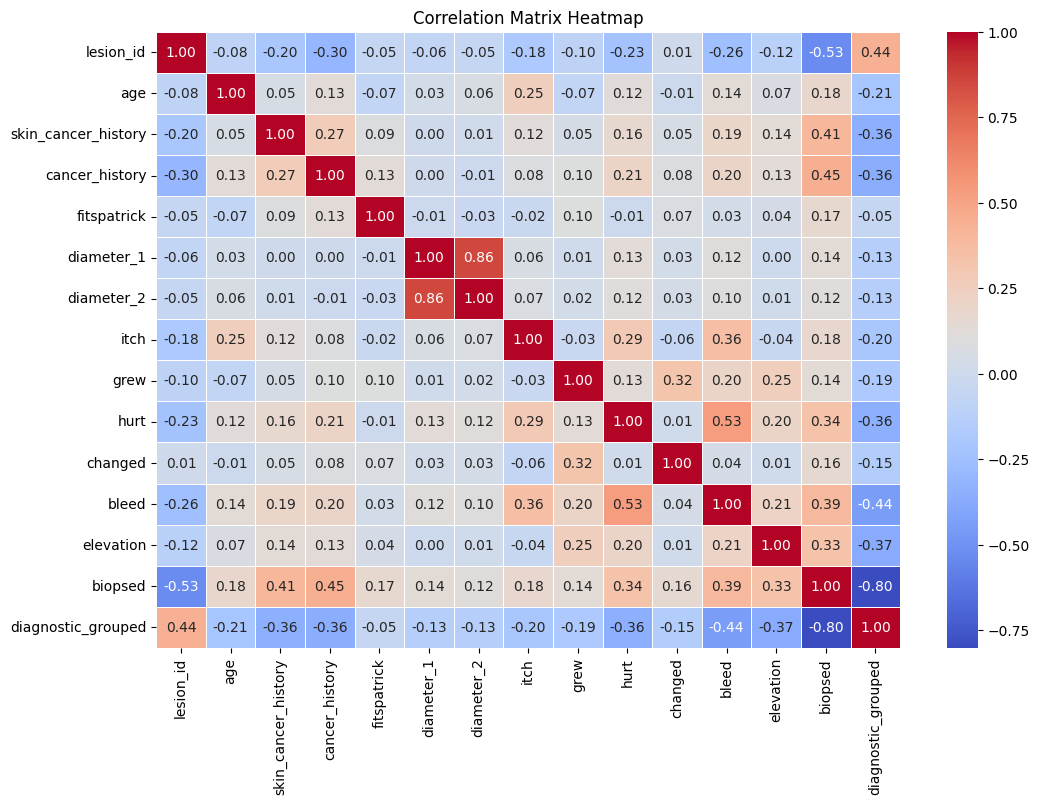

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_metadata = metadata.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_metadata.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
metadata = pd.get_dummies(metadata, columns=['region'], drop_first=True)

In [28]:
print(metadata.columns)

Index(['patient_id', 'lesion_id', 'age', 'skin_cancer_history',
       'cancer_history', 'fitspatrick', 'diameter_1', 'diameter_2', 'itch',
       'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed',
       'diagnostic_grouped', 'region_ARM', 'region_BACK', 'region_CHEST',
       'region_EAR', 'region_FACE', 'region_FOOT', 'region_FOREARM',
       'region_HAND', 'region_LIP', 'region_NECK', 'region_NOSE',
       'region_SCALP', 'region_THIGH'],
      dtype='object')


In [ ]:
region_cols = [col for col in metadata.columns if col.startswith("region_")]
metadata[region_cols] = metadata[region_cols].astype(int)

In [ ]:
import os
image_folders = [
    "/kaggle/input/skin-cancer/imgs_part_1/imgs_part_1",
    "/kaggle/input/skin-cancer/imgs_part_2/imgs_part_2",
    "/kaggle/input/skin-cancer/imgs_part_3/imgs_part_3"
]

def find_image_path(img_id):
    """Search for an image in multiple folders and return its full path if found."""
    for folder in image_folders:
        img_path = os.path.join(folder, img_id)
        if os.path.exists(img_path):
            return img_path
    return None  
metadata["image_path"] = metadata["img_id"].apply(find_image_path)
metadata = metadata.dropna(subset=["image_path"])
metadata.to_csv("/kaggle/working/metadata_with_images.csv", index=False)
print(f"Final metadata size after removing missing images: {metadata.shape}")


Final metadata size after removing missing images: (2298, 31)


In [ ]:
import pandas as pd
metadata = pd.read_csv('/kaggle/working/metadata_with_images.csv')
print(metadata.head())
print(metadata.info())
print(metadata.isnull().sum())

  patient_id  lesion_id       age  skin_cancer_history  cancer_history  \
0   PAT_1516       1765 -3.301454                    0               0   
1     PAT_46        881 -0.343881                    1               1   
2   PAT_1545       1867  1.040515                    0               0   
3   PAT_1989       4061  0.914661                    0               0   
4    PAT_684       1302  1.166369                    1               0   

   fitspatrick  diameter_1  diameter_2  itch  grew  ...  region_FACE  \
0    -0.287388   -0.175732   -0.118127   0.0   0.0  ...            0   
1     1.376130   -0.745672   -0.757749   1.0   1.0  ...            0   
2    -0.287388   -0.175732   -0.118127   1.0   0.0  ...            1   
3    -0.287388   -0.175732   -0.118127   1.0   0.0  ...            0   
4    -1.950906   -0.888157   -0.757749   1.0   1.0  ...            0   

   region_FOOT  region_FOREARM  region_HAND region_LIP  region_NECK  \
0            0               0            0        

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
metadata_path = "/kaggle/working/metadata_with_images.csv"  
metadata = pd.read_csv(metadata_path)
image_folders = ["/kaggle/input/skin-cancer/imgs_part_1/imgs_part_1", "/kaggle/input/skin-cancer/imgs_part_2/imgs_part_2", "/kaggle/input/skin-cancer/imgs_part_3/imgs_part_3"]  # Define your image folders

def get_image_path(img_id, folders):
    for folder in folders:
        img_path = os.path.join(folder, img_id)  
        if os.path.exists(img_path):  
            return img_path
    return None  
metadata['img_id'] = metadata['img_id'].apply(lambda x: get_image_path(x, image_folders))
metadata = metadata.dropna(subset=["img_id"])
IMG_SIZE = (224, 224) 
preprocessed_images = []
for img_path in tqdm(metadata["img_id"]):  
    if os.path.exists(img_path):  
        img = cv2.imread(img_path)  
        img = cv2.resize(img, IMG_SIZE) 
        img = img / 255.0  
        preprocessed_images.append(img)
    else:
        print(f"Warning: {img_path} not found!")
preprocessed_images = np.array(preprocessed_images, dtype=np.float32)

100%|██████████| 2298/2298 [01:20<00:00, 28.64it/s]


In [ ]:
np.save("/kaggle/working/preprocessed_images.npy", preprocessed_images)  # Update path
print(f"✅ Preprocessed {preprocessed_images.shape[0]} images successfully!")

✅ Preprocessed 2298 images successfully!


In [ ]:
preprocessed_images = np.load("/kaggle/working/preprocessed_images.npy")
print(f"Preprocessed images shape: {preprocessed_images.shape}")

Preprocessed images shape: (2298, 224, 224, 3)


In [ ]:
import pandas as pd
metadata = pd.read_csv("/kaggle/working/metadata_with_images.csv")

In [ ]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(metadata, test_size=0.3, stratify=metadata['diagnostic_grouped'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['diagnostic_grouped'], random_state=42)
train_df.to_csv("/kaggle/working/train_metadata.csv", index=False)
val_df.to_csv("/kaggle/working/val_metadata.csv", index=False)
test_df.to_csv("/kaggle/working/test_metadata.csv", index=False)

In [ ]:
import numpy as np
all_images = np.load("/kaggle/working/preprocessed_images.npy")

In [ ]:
img_paths = metadata['image_path'].tolist()  
img_id_to_index = {img_path: idx for idx, img_path in enumerate(img_paths)}
train_indices = [img_id_to_index[img_id] for img_id in train_df['image_path']]
val_indices = [img_id_to_index[img_id] for img_id in val_df['image_path']]
test_indices = [img_id_to_index[img_id] for img_id in test_df['image_path']]

In [ ]:
X_train_images = all_images[train_indices]
X_val_images = all_images[val_indices]
X_test_images = all_images[test_indices]

In [ ]:
metadata_cols = [col for col in metadata.columns if col not in ['patient_id', 'lesion_id', 'img_id', 'image_path', 'diagnostic_grouped']]
X_train_meta = train_df[metadata_cols].values
X_val_meta = val_df[metadata_cols].values
X_test_meta = test_df[metadata_cols].values
y_train = train_df['diagnostic_grouped'].values
y_val = val_df['diagnostic_grouped'].values
y_test = test_df['diagnostic_grouped'].values

In [ ]:
import numpy as np
images = np.load('/kaggle/working/preprocessed_images.npy')
print(images.shape)  

(2298, 224, 224, 3)


In [ ]:
import tensorflow as tf
_ = tf.random.normal([10, 10])

2025-04-13 05:44:25.403900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744523065.421674     316 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744523065.426754     316 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1744523068.539739     316 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1744523068.540356     316 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

In [44]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [45]:
# Warmup
_ = tf.random.normal([10, 10])

In [ ]:
image_input = layers.Input(shape=(224, 224, 3))
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
image_model = Model(inputs=image_input, outputs=x)

In [ ]:
metadata_input = layers.Input(shape=(X_train_meta.shape[1],))
metadata_x = layers.Dense(128, activation='relu')(metadata_input)
metadata_x = layers.Dense(64, activation='relu')(metadata_x)
metadata_model = Model(inputs=metadata_input, outputs=metadata_x)

In [ ]:
combined_input = layers.concatenate([image_model.output, metadata_model.output])
x = layers.Dense(128, activation='relu')(combined_input)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)  

In [ ]:
model = Model(inputs=[image_model.input, metadata_model.input], outputs=output)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = {0: 1.0, 1: 2.0} 
history = model.fit(
    [images[train_indices], X_train_meta],
    y_train,
    class_weight=class_weights,
    validation_data=([images[val_indices], X_val_meta], y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


I0000 00:00:1744523180.762216     363 service.cc:148] XLA service 0x7bd488157d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744523180.762258     363 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1744523180.762263     363 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1744523189.967699     363 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744523274.819401     363 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


51/51 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.5816 - loss: 0.8870 - val_accuracy: 0.6551 - val_loss: 0.6434
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.8872 - loss: 0.3483 - val_accuracy: 0.6870 - val_loss: 0.6961
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - accuracy: 0.9686 - loss: 0.1179 - val_accuracy: 0.7246 - val_loss: 0.7450
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.9812 - loss: 0.0713 - val_accuracy: 0.6957 - val_loss: 0.8853
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - accuracy: 0.9919 - loss: 0.0425 - val_accuracy: 0.7304 - val_loss: 0.9043
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.9875 - loss: 0.0438 - val_accuracy: 0.7797 - val_loss: 0.7030
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.9562 - loss: 0.1703 - val_accuracy: 0.7014 - val_loss: 0.9066
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.9552 - loss: 0.1540 - val_accuracy: 0.7101 

In [ ]:
test_loss, test_accuracy = model.evaluate([images[test_indices], X_test_meta], y_test)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8600 - loss: 0.4271

✅ Test Accuracy: 0.8522
✅ Test Loss: 0.4144


In [ ]:
y_pred = model.predict([images[test_indices], X_test_meta])
y_pred_binary = (y_pred > 0.5).astype(int)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_binary))

11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       164
           1       0.85      0.87      0.86       181

    accuracy                           0.85       345
   macro avg       0.85      0.85      0.85       345
weighted avg       0.85      0.85      0.85       345



In [54]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [55]:
# 1. Warmup TensorFlow GPU (optional but helps reduce initial lag)
_ = tf.random.normal([10, 10])

In [ ]:
image_input = layers.Input(shape=(224, 224, 3))
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
image_model = Model(inputs=image_input, outputs=x)

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
metadata_input = layers.Input(shape=(X_train_meta.shape[1],))
meta_x = layers.Dense(128, activation='relu')(metadata_input)
meta_x = layers.Dense(64, activation='relu')(meta_x)
metadata_model = Model(inputs=metadata_input, outputs=meta_x)

In [ ]:
combined = layers.concatenate([image_model.output, metadata_model.output])
x = layers.Dense(128, activation='relu')(combined)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x) 

In [ ]:
model = Model(inputs=[image_model.input, metadata_model.input], outputs=output)

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = {0: 1.0, 1: 2.0}  
history = model.fit(
    [images[train_indices], X_train_meta],
    y_train,
    validation_data=([images[val_indices], X_val_meta], y_val),
    class_weight=class_weights,
    epochs=10,
    batch_size=32
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.5578 - loss: 0.9416 - val_accuracy: 0.6928 - val_loss: 0.7543
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 559ms/step - accuracy: 0.8879 - loss: 0.3884 - val_accuracy: 0.6928 - val_loss: 1.1503
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step - accuracy: 0.9593 - loss: 0.1523 - val_accuracy: 0.7449 - val_loss: 1.2355
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step - accuracy: 0.9750 - loss: 0.0950 - val_accuracy: 0.7739 - val_loss: 0.8591
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 548ms/step - accuracy: 0.9777 - loss: 0.0891 - val_accuracy: 0.7942 - val_loss: 0.9275
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 546ms/step - accuracy: 0.9925 - loss: 0.0570 - val_accuracy: 0.7913 - val_loss: 1.0180
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step - accuracy: 0.9883 - loss: 0.0385 - val_accuracy: 0.7855 - val_loss: 0.8627
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step - accuracy: 0.9923 - loss: 0.0398 - val_accura

In [ ]:
test_loss, test_accuracy = model.evaluate([images[test_indices], X_test_meta], y_test)
print(f"✅ Test Accuracy: {test_accuracy:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.8113 - loss: 1.0546
✅ Test Accuracy: 0.8029
✅ Test Loss: 1.1379


In [ ]:
y_pred = model.predict([images[test_indices], X_test_meta])
y_pred_binary = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred_binary))

11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step 
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       164
           1       0.76      0.91      0.83       181

    accuracy                           0.80       345
   macro avg       0.82      0.80      0.80       345
weighted avg       0.81      0.80      0.80       345



In [64]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

In [ ]:
image_input = layers.Input(shape=(224, 224, 3)) 
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model(image_input)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
image_model = Model(inputs=image_input, outputs=x)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
metadata_input = layers.Input(shape=(X_train_meta.shape[1],))  # X_train_meta is your metadata input
metadata_x = layers.Dense(128, activation='relu')(metadata_input)
metadata_x = layers.Dense(64, activation='relu')(metadata_x)
metadata_model = Model(inputs=metadata_input, outputs=metadata_x)

In [ ]:
combined_input = layers.concatenate([image_model.output, metadata_model.output])
x = layers.Dense(128, activation='relu')(combined_input)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x) 

In [ ]:
model = Model(inputs=[image_model.input, metadata_model.input], outputs=output)

In [ ]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = {0: 1.0, 1: 2.0}  
history = model.fit(
    [images[train_indices], X_train_meta],  
    y_train,
    class_weight=class_weights,
    validation_data=([images[val_indices], X_val_meta], y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


E0000 00:00:1744524376.718484     361 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744524376.858098     361 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.6331 - loss: 0.8568 - val_accuracy: 0.7797 - val_loss: 0.4337
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9020 - loss: 0.4039 - val_accuracy: 0.7507 - val_loss: 0.4596
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9088 - loss: 0.3190 - val_accuracy: 0.7507 - val_loss: 0.4995
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.9184 - loss: 0.3053 - val_accuracy: 0.8232 - val_loss: 0.3934
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.9415 - loss: 0.2341 - val_accuracy: 0.7014 - val_loss: 0.8693
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9468 - loss: 0.2195 - val_accuracy: 0.8609 - val_loss: 0.2962
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9468 - loss: 0.1988 - val_accuracy: 0.7739 - val_loss: 0.4941
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9496 - loss: 0.1424 - val_accuracy: 0.7855 - val_l

In [ ]:
test_loss, test_accuracy = model.evaluate([images[test_indices], X_test_meta], y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9511 - loss: 0.1526
Test Accuracy: 0.9275
Test Loss: 0.2082


In [ ]:
y_pred = model.predict([images[test_indices], X_test_meta])
y_pred_binary = (y_pred > 0.5).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_binary))

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 726ms/step
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       164
           1       0.98      0.88      0.93       181

    accuracy                           0.93       345
   macro avg       0.93      0.93      0.93       345
weighted avg       0.93      0.93      0.93       345



In [ ]:
model.save('/kaggle/working/densenet_multimodal_model.keras')


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('densenet_multimodal_model.keras')

In [ ]:
model.save('/kaggle/working/efficientnetv2_multimodal_model.keras')

In [ ]:
from tensorflow.keras.models import load_model
efficientnetv2_model = load_model('/kaggle/working/efficientnetv2_multimodal_model.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 508 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.save('/kaggle/working/inceptionresnetv2_multimodal_model.keras')

In [ ]:
from tensorflow.keras.models import load_model
inceptionresnet_model = load_model('/kaggle/working/inceptionresnetv2_multimodal_model.keras')

In [ ]:
from tensorflow.keras.models import load_model
densenet_model = load_model('/kaggle/working/densenet_multimodal_model.keras')
inception_model = load_model('/kaggle/working/inceptionresnetv2_multimodal_model.keras')
efficientnet_model = load_model('/kaggle/working/efficientnetv2_multimodal_model.keras')

In [ ]:
densenet_preds = densenet_model.predict([images[test_indices], X_test_meta])
inception_preds = inception_model.predict([images[test_indices], X_test_meta])
efficientnet_preds = efficientnet_model.predict([images[test_indices], X_test_meta])

11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 628ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 615ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 585ms/step


In [ ]:
import numpy as np
avg_preds = (densenet_preds + inception_preds + efficientnet_preds) / 3.0
y_pred_ensemble = (avg_preds > 0.5).astype(int)


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
print("✅ Ensemble Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("\n📊 Ensemble Classification Report:")
print(classification_report(y_test, y_pred_ensemble))


✅ Ensemble Accuracy: 0.927536231884058

📊 Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       164
           1       0.98      0.88      0.93       181

    accuracy                           0.93       345
   macro avg       0.93      0.93      0.93       345
weighted avg       0.93      0.93      0.93       345



In [ ]:
densenet_weight = 0.2
inception_weight = 0.2
efficientnet_weight = 0.6
ensemble_preds = (
    densenet_weight * densenet_preds +
    inception_weight * inception_preds +
    efficientnet_weight * efficientnet_preds
)
ensemble_labels = (ensemble_preds > 0.5).astype(int)



In [ ]:
from sklearn.metrics import classification_report, accuracy_score
accuracy = accuracy_score(y_test, ensemble_labels)
print(f"\n✅ Weighted Ensemble Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, ensemble_labels))



✅ Weighted Ensemble Accuracy: 0.9275

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       164
           1       0.98      0.88      0.93       181

    accuracy                           0.93       345
   macro avg       0.93      0.93      0.93       345
weighted avg       0.93      0.93      0.93       345



In [ ]:
from tensorflow.keras.models import load_model
densenet_model = load_model('/kaggle/working/densenet_multimodal_model.keras')
inception_model = load_model('/kaggle/working/inceptionresnetv2_multimodal_model.keras')
efficientnet_model = load_model('/kaggle/working/efficientnetv2_multimodal_model.keras')


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 508 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
dense_val_preds = densenet_model.predict([images[val_indices], X_val_meta]).flatten()
inception_val_preds = inception_model.predict([images[val_indices], X_val_meta]).flatten()
efficient_val_preds = efficientnet_model.predict([images[val_indices], X_val_meta]).flatten()
dense_test_preds = densenet_model.predict([images[test_indices], X_test_meta]).flatten()
inception_test_preds = inception_model.predict([images[test_indices], X_test_meta]).flatten()
efficient_test_preds = efficientnet_model.predict([images[test_indices], X_test_meta]).flatten()

11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 875ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 606ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 593ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
val_stack = np.stack([dense_val_preds, inception_val_preds, efficient_val_preds], axis=1)
test_stack = np.stack([dense_test_preds, inception_test_preds, efficient_test_preds], axis=1)
from sklearn.neural_network import MLPClassifier
meta_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000)
meta_model.fit(val_stack, y_val)
stacked_preds = meta_model.predict(test_stack)
accuracy = accuracy_score(y_test, stacked_preds)
print(f"\n✅ Stacking Ensemble Accuracy: {accuracy:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, stacked_preds))



✅ Stacking Ensemble Accuracy: 0.9275

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       164
           1       0.98      0.88      0.93       181

    accuracy                           0.93       345
   macro avg       0.93      0.93      0.93       345
weighted avg       0.93      0.93      0.93       345



In [ ]:
import joblib
joblib.dump(meta_model, '/kaggle/working/meta_model.pkl')

['/kaggle/working/meta_model.pkl']